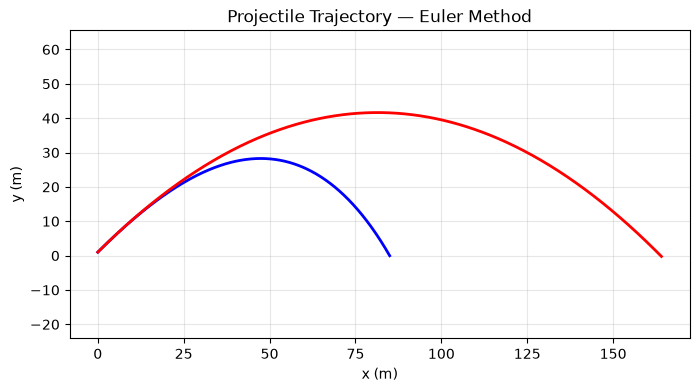

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Physical parameters
g = 9.81
m = 0.145         # mass of a baseball, kg
r = 0.0366        # radius of a baseball, m
Cd = 0.47         # drag coefficient for a sphere
rho = 1.225       # air density, kg/m³
A = np.pi * r**2  # cross-sectional area

# Combine the drag constants into one number
b = 0.5 * Cd * rho * A  # so F_drag = -b * |v| * v

dt = 0.01
v0 = 40.0  # ~90 mph fastball
angle = np.radians(45)

# Initial state
x, y = 0.0, 1.0   # released from 1 m height
vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

xs_drag, ys_drag = [x], [y]

# Euler integration loop
t = 0.0
while y >= 0.0:
    # Speed (magnitude of velocity)
    speed = np.sqrt(vx**2 + vy**2)

    # Forces: gravity + drag
    Fx = -(b / m) * speed * vx
    Fy = -g - (b / m) * speed * vy

    # Euler update
    vx += Fx * dt
    vy += Fy * dt
    x += vx * dt
    y += vy * dt

    t += dt
    xs_drag.append(x)
    ys_drag.append(y)

# Re-initialize state
x, y = 0.0, 1.0   # released from 1 m height
vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

xs, ys = [x], [y]

# Euler integration loop
t = 0.0

while y >= 0.0:
    # Compute acceleration (only gravity here)
    ax = 0.0
    ay = -g

    # Update velocity (Euler)
    vx = vx + ax * dt
    vy = vy + ay * dt

    # Update position (Euler)
    x = x + vx * dt
    y = y + vy * dt

    t += dt
    xs.append(x)
    ys.append(y)
  



# Plot trajectory
plt.figure(figsize=(8, 4))
plt.plot(xs_drag, ys_drag, 'b-', linewidth=2)
plt.plot(xs, ys, 'r-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()